In [1]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Simplifide 2D example (real embeddings have hundreds of dimensions)

word_embeddings = {
    "cat": [0.8, 0.6],
    "kitten": [0.75, 0.65],
    "dog": [0.7, 0.3],
    "puppy": [0.65, 0.35],
    "car": [-0.5, 0.2],
    "truck": [-0.45, 0.15]
}

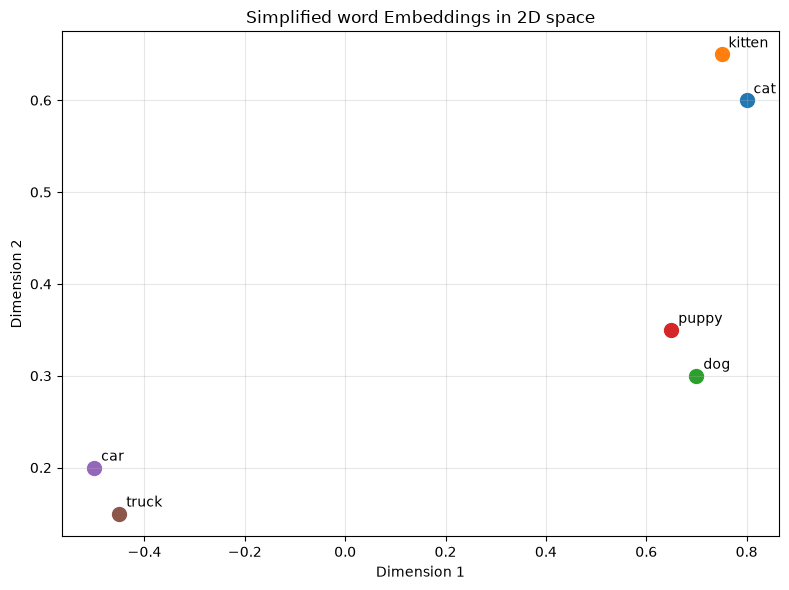

In [4]:
fig, ax = plt.subplots(figsize=(8,6))

for word, coords in word_embeddings.items():
    ax.scatter(coords[0], coords[1], s=100)
    ax.annotate(word, (coords[0], coords[1]), xytext = (5,5), textcoords="offset points")

ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_title('Simplified word Embeddings in 2D space')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Measuring Similarity

In [5]:
def cosine_similarity(vec1, vec2):
    """
    Cosine similarity measures the angles between two vectors.
    - Result close to 1: Very similar
    - Result close to 0: Not related
    - Result close to -1: Opposit meaning
    """

    dot_product = np.dot(vec1, vec2)
    norm_a = np.linalg.norm(vec1)
    norm_b = np.linalg.norm(vec2)
    return dot_product / (norm_a * norm_b)

In [6]:
# Example
cat_vector = [0.8, 0.6, 0.3]
kitten_vector = [0.75, 0.65, 0.35]
car_vector = [-0.5, 0.2, 0.1]

cat_kitten_similarity = cosine_similarity(cat_vector, kitten_vector)
print(cat_kitten_similarity)

0.9966186334192181


In [7]:
car_cat_similarity = cosine_similarity(car_vector, cat_vector)
print(car_cat_similarity)

-0.43718588548916804


# Embedding


In [8]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

HUGGING_FACE_EMBEDDING_MODEL = os.getenv("HUGGING_FACE_EMBEDDING_MODEL")
print(HUGGING_FACE_EMBEDDING_MODEL)

sentence-transformers/all-MiniLM-L6-v2


In [9]:
from langchain_huggingface import HuggingFaceEmbeddings

# Initialize a simple Embedding model(No api key needed)
embeddings = HuggingFaceEmbeddings(
    model_name = HUGGING_FACE_EMBEDDING_MODEL
)

embeddings

/Users/mdirfan/dev/python/agentic-ai/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 17664.20it/s]


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [10]:
## Create your first embeddings

text = "Hello, I am learning about embedding, and vector databases"

embedding = embeddings.embed_query(text)

print(f"Text: {text}")
print(f"Embedding length: {len(embedding)}")
print(f"Embedding: {embedding}")

Text: Hello, I am learning about embedding, and vector databases
Embedding length: 384
Embedding: [0.036709487438201904, -0.1353401094675064, -0.04774836078286171, 0.022877661511301994, 0.00013752303493674845, 0.0280842836946249, -0.023868178948760033, -0.0004485747485887259, -0.05229151248931885, -0.03086142987012863, -0.012731725350022316, 0.051210131496191025, 0.0840974748134613, 0.003362481016665697, -0.10024548321962357, 0.058754779398441315, 0.03259659558534622, 0.05359466001391411, 0.006927824113518, -0.005215856712311506, -0.06144683063030243, -0.03143993020057678, -0.02764795534312725, -0.055602021515369415, 0.03972127288579941, -0.0006436948897317052, 0.025413958355784416, 0.04280247911810875, 0.032263532280921936, -0.061439722776412964, 0.027877338230609894, 0.0022174937184900045, 0.023427482694387436, 0.10463615506887436, -0.08745674788951874, 0.053562313318252563, 0.04150211066007614, -0.031424008309841156, -0.12489045411348343, -0.015962865203619003, 0.015664273872971535,

In [ ]:
sentences = [
    "The cat sat quietly on the windowsill, watching birds in the garden.",
    "Artificial intelligence is transforming how businesses make decisions.",
    "She poured herself a cup of coffee and opened her laptop.",
    "The stock market experienced significant volatility last quarter.",
    "Climate change poses one of the greatest challenges to modern civilization.",
    "He learned to play the piano at the age of seven.",
    "The restaurant serves authentic Italian cuisine in a cozy atmosphere.",
    "Machine learning models require large amounts of training data.",
    "The hikers reached the mountain summit just before sunset.",
    "Online shopping has fundamentally changed consumer behavior.",
    "The novel explores themes of love, loss, and redemption.",
    "Regular exercise improves both physical and mental health.",
    "The spacecraft successfully landed on the surface of Mars.",
    "She speaks four languages fluently, including Mandarin and Spanish.",
    "The company announced a new sustainability initiative to reduce carbon emissions.",
    "Children learn best through play and hands-on exploration.",
    "The ancient library contained thousands of rare manuscripts.",
    "Cybersecurity threats are becoming increasingly sophisticated.",
    "He proposed to his girlfriend on a beach in Hawaii.",
    "Renewable energy sources like solar and wind are growing rapidly."
]

embedding_sentence = embeddings.embed_documents(sentences)

for embed in embedding_sentence:
    print(embed)

[0.11068493872880936, -0.03722193464636803, 0.015946729108691216, 0.045515965670347214, -0.010023127309978008, -0.004670983646064997, 0.04713710770010948, -0.08089271932840347, 0.033400166779756546, 0.010339557193219662, -0.035834748297929764, -0.002876904094591737, 0.029162270948290825, -0.008691392838954926, -0.04670267924666405, -0.01305578276515007, -0.02372601628303528, 0.042469535022974014, 0.003342370269820094, 0.02593153901398182, -0.05894767493009567, 0.041294440627098083, 0.06280085444450378, 0.01264952402561903, 0.016459021717309952, 0.06158415973186493, -0.046119868755340576, -0.0009919841540977359, -0.009141094982624054, -0.006527957506477833, -0.00036784031544812024, 0.013909561559557915, -0.04077586531639099, 0.06345535069704056, -0.0037139798514544964, -0.05906993895769119, 0.05768139287829399, -0.07242559641599655, 0.08083299547433853, -0.033193863928318024, -0.006248209159821272, -0.01204074639827013, -0.013629690743982792, -0.09476334601640701, -0.035620786249637604,

In [15]:
query = "What is machine learning?"

In [17]:
def semantic_search(query, sentences, embedding_models, top_k = 3):
    """Simple semantic search implementation"""
    query_embedding = embedding_models.embed_query(query)
    sentence_embeddings = embedding_models.embed_documents(sentences)

    similarities = []

    for i, doc_emb in enumerate(sentence_embeddings):
        similarity = cosine_similarity(query_embedding, doc_emb)
        similarities.append((similarity, sentences[i]))

    similarities.sort(reverse=True)
    return similarities[:top_k]

In [18]:
results = semantic_search(query, sentences, embeddings)

results

[(np.float64(0.5215410974120435),
  'Machine learning models require large amounts of training data.'),
 (np.float64(0.4307813583531106),
  'Artificial intelligence is transforming how businesses make decisions.'),
 (np.float64(0.1890507036124421),
  'Cybersecurity threats are becoming increasingly sophisticated.')]